<a href="https://colab.research.google.com/github/MariamHazem226/AI-in-Software-Debugging-Research/blob/main/Visualizations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


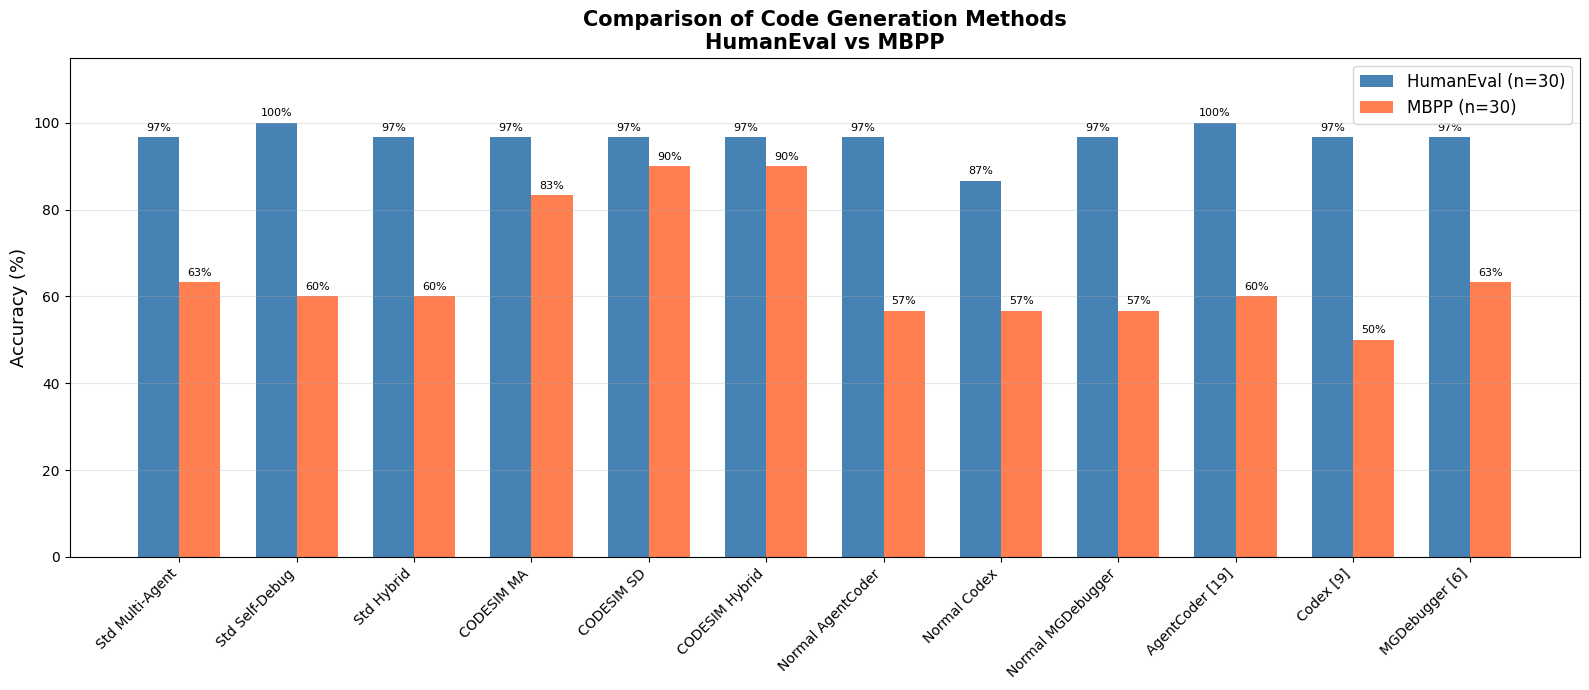

Saved: fig1_humaneval_vs_mbpp.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import json

with open("/content/drive/MyDrive/results_humaneval.json") as f:
    humaneval = json.load(f)

with open("/content/drive/MyDrive/results_mbpp.json") as f:
    mbpp = json.load(f)

labels = [
    "Std Multi-Agent",
    "Std Self-Debug",
    "Std Hybrid",
    "CODESIM MA",
    "CODESIM SD",
    "CODESIM Hybrid",
    "Normal AgentCoder",
    "Normal Codex",
    "Normal MGDebugger",
    "AgentCoder [19]",
    "Codex [9]",
    "MGDebugger [6]"
]

keys = [
    "standard_ma", "standard_sd", "standard_hybrid",
    "codesim_ma", "codesim_sd", "codesim_hybrid",
    "normal_agentcoder", "normal_codex", "normal_mgdebugger",
    "ref_agentcoder", "ref_codex", "ref_mgdebugger"
]

he_vals = [humaneval.get(k, 0) for k in keys]
mbpp_vals = [mbpp.get(k, 0) for k in keys]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 7))

bars1 = ax.bar(x - width/2, he_vals, width, label='HumanEval (n=30)', color='steelblue')
bars2 = ax.bar(x + width/2, mbpp_vals, width, label='MBPP (n=30)', color='coral')

ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title('Comparison of Code Generation Methods\nHumanEval vs MBPP', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
ax.set_ylim(0, 115)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1,
                f'{h:.0f}%', ha='center', va='bottom', fontsize=8)

for bar in bars2:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1,
                f'{h:.0f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/fig1_humaneval_vs_mbpp.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig1_humaneval_vs_mbpp.png")

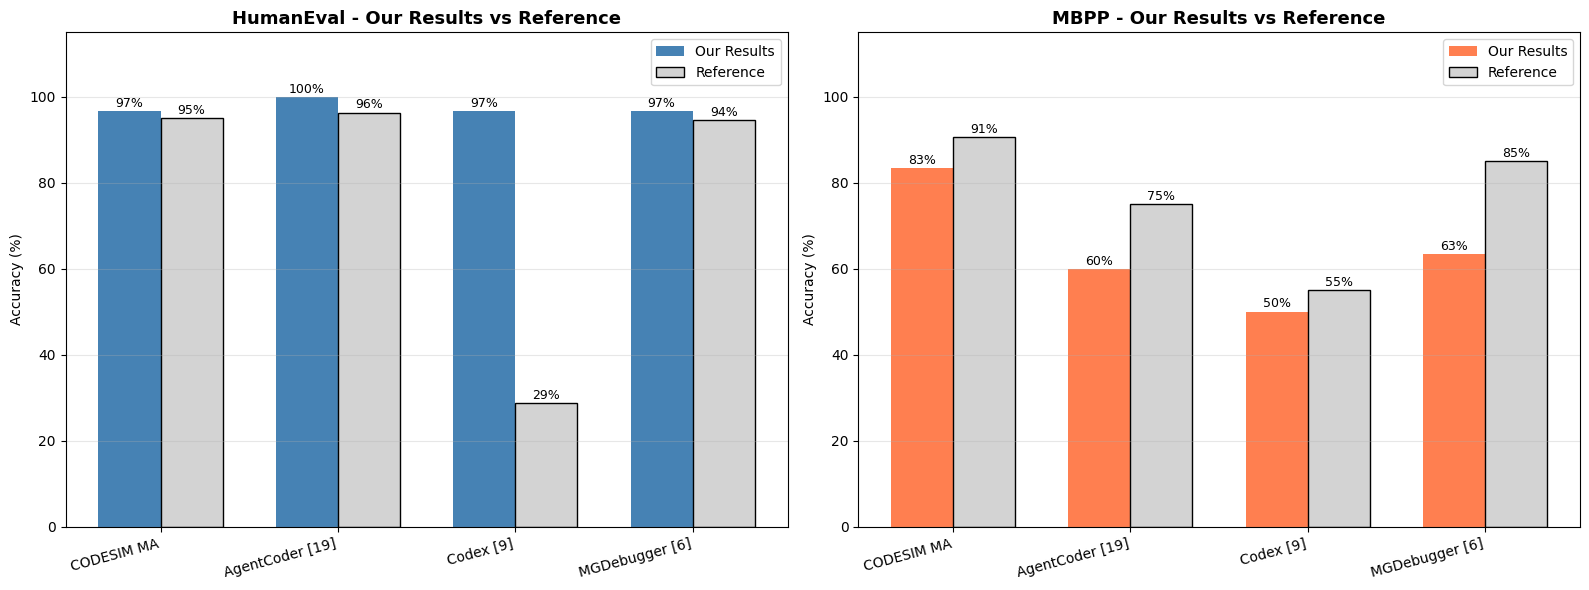

Saved: fig2_vs_references.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ref_methods = ["CODESIM MA", "AgentCoder [19]", "Codex [9]", "MGDebugger [6]"]
our_he = [humaneval.get("codesim_ma", 0), humaneval.get("ref_agentcoder", 0),
          humaneval.get("ref_codex", 0), humaneval.get("ref_mgdebugger", 0)]
ref_he = [95.1, 96.3, 28.8, 94.5]

our_mbpp = [mbpp.get("codesim_ma", 0), mbpp.get("ref_agentcoder", 0),
            mbpp.get("ref_codex", 0), mbpp.get("ref_mgdebugger", 0)]
ref_mbpp = [90.7, 75.0, 55.0, 85.0]

x = np.arange(len(ref_methods))
width = 0.35

# HumanEval
axes[0].bar(x - width/2, our_he, width, label='Our Results', color='steelblue')
axes[0].bar(x + width/2, ref_he, width, label='Reference', color='lightgray', edgecolor='black')
axes[0].set_title('HumanEval - Our Results vs Reference', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(ref_methods, rotation=15, ha='right')
axes[0].set_ylim(0, 115)
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

for i, (o, r) in enumerate(zip(our_he, ref_he)):
    axes[0].text(i - width/2, o + 1, f'{o:.0f}%', ha='center', fontsize=9)
    axes[0].text(i + width/2, r + 1, f'{r:.0f}%', ha='center', fontsize=9)

# MBPP
axes[1].bar(x - width/2, our_mbpp, width, label='Our Results', color='coral')
axes[1].bar(x + width/2, ref_mbpp, width, label='Reference', color='lightgray', edgecolor='black')
axes[1].set_title('MBPP - Our Results vs Reference', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(ref_methods, rotation=15, ha='right')
axes[1].set_ylim(0, 115)
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

for i, (o, r) in enumerate(zip(our_mbpp, ref_mbpp)):
    axes[1].text(i - width/2, o + 1, f'{o:.0f}%', ha='center', fontsize=9)
    axes[1].text(i + width/2, r + 1, f'{r:.0f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/fig2_vs_references.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig2_vs_references.png")

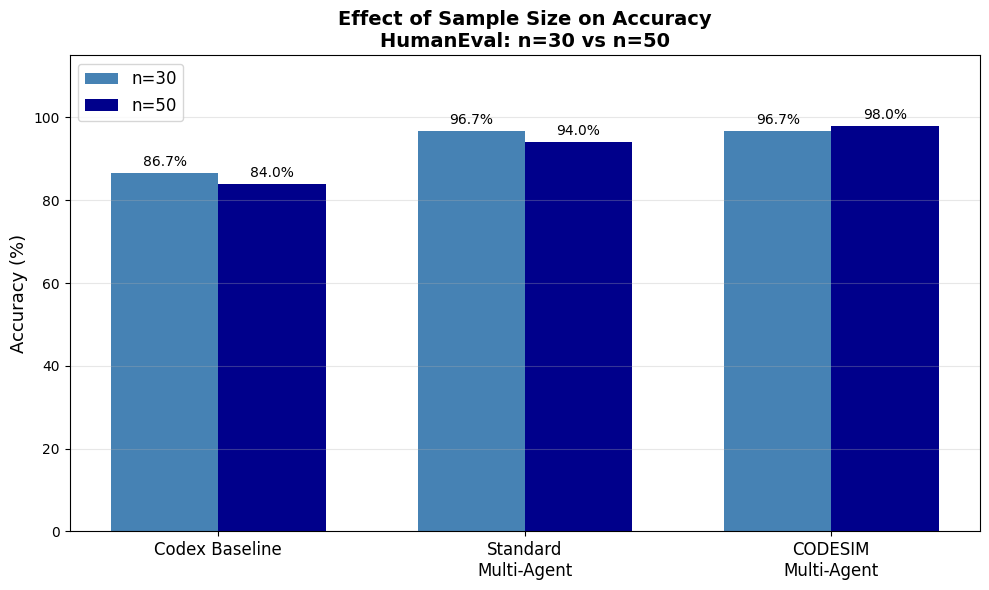

Saved: fig3_sample_size_effect.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

methods = ["Codex Baseline", "Standard\nMulti-Agent", "CODESIM\nMulti-Agent"]

n30_vals = [
    humaneval.get("normal_codex", 0),
    humaneval.get("standard_ma", 0),
    humaneval.get("codesim_ma", 0)
]

n50_vals = [
    humaneval.get("codex_50", 0),
    humaneval.get("standard_ma_50", 0),
    humaneval.get("codesim_ma_50", 0)
]

x = np.arange(len(methods))
width = 0.35

bars1 = ax.bar(x - width/2, n30_vals, width, label='n=30', color='steelblue')
bars2 = ax.bar(x + width/2, n50_vals, width, label='n=50', color='darkblue')

ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title('Effect of Sample Size on Accuracy\nHumanEval: n=30 vs n=50', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=12)
ax.set_ylim(0, 115)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/fig3_sample_size_effect.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig3_sample_size_effect.png")

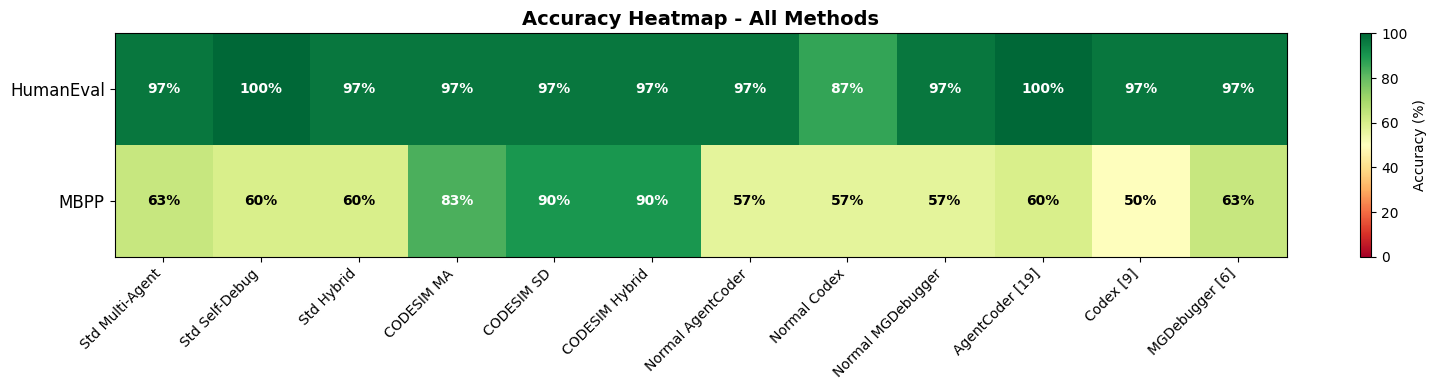

Saved: fig4_heatmap.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

methods_labels = [
    "Std Multi-Agent", "Std Self-Debug", "Std Hybrid",
    "CODESIM MA", "CODESIM SD", "CODESIM Hybrid",
    "Normal AgentCoder", "Normal Codex", "Normal MGDebugger",
    "AgentCoder [19]", "Codex [9]", "MGDebugger [6]"
]

he_vals = [humaneval.get(k, 0) for k in keys]
mbpp_vals = [mbpp.get(k, 0) for k in keys]

data = np.array([he_vals, mbpp_vals])

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)

ax.set_xticks(np.arange(len(methods_labels)))
ax.set_yticks(np.arange(2))
ax.set_xticklabels(methods_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(['HumanEval', 'MBPP'], fontsize=12)

for i in range(2):
    for j in range(len(methods_labels)):
        val = data[i, j]
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='black' if 30 < val < 80 else 'white')

plt.colorbar(im, ax=ax, label='Accuracy (%)')
ax.set_title('Accuracy Heatmap - All Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/fig4_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig4_heatmap.png")